### **I. Importation des bibliothéques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pycaret.clustering import *

### **II. Exploration de donnée**

#### **1. Importation de donnée**

In [2]:
data = pd.read_csv('../data/jewellery.csv')
data.head()

,Age,Income,SpendingScore,Savings
0,58,77769,0.791329,6559.829923
1,59,81799,0.791082,5417.661426
2,62,74751,0.702657,9258.992965
3,59,74373,0.765680,7346.334504
4,87,17760,0.348778,16869.507130


**Information de donnée**

In [3]:
print(data.shape)
data.info()

(505, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            505 non-null    int64  
 1   Income         505 non-null    int64  
 2   SpendingScore  505 non-null    float64
 3   Savings        505 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 15.9 KB


#### **2. Etude des variables**
**Income** : revenu d’un individu ou d’un ménage, généralement exprimé en argent gagné par mois ou par an.

**SpendingScore** : score de dépense attribué à une personne selon ses habitudes d’achat, sa fréquence et le montant de ses dépenses. C’est souvent une variable utilisée en marketing pour segmenter les clients.

**Savings** : épargne, c’est-à-dire la part du revenu qui n’est pas dépensée et qui est mise de côté (par exemple sur un compte bancaire).

> Les données que nous avons ici ne correspondent pas clairement à un problème de régression ou de classification, car aucune variable cible (ou label) n’est définie.  
> Cela suggère qu’il s’agit d’un problème de segmentation, ce qui nous conduit naturellement vers une approche de clustering non supervisé.

**Buts principaux de l’étude**\
Avec ces variables, une étude de cluster sert en général à :
- Segmenter les clients en groupes homogènes (jeunes gros dépensiers avec peu d’épargne, seniors prudents avec beaucoup d’épargne, middle income etc.).​
- Aider le marketing à cibler des offres différentes selon les segments (produits de luxe, épargne, crédit, promotions, etc.)

**Renommage des variables pour une meilleure compréhension de l’étude.**

In [4]:
data.rename(columns={'Income':'revenu',
                     'SpendingScore': 'depense',
                     'Savings':'epargne'},inplace=True)

In [5]:
data.head()

,Age,revenu,depense,epargne
0,58,77769,0.791329,6559.829923
1,59,81799,0.791082,5417.661426
2,62,74751,0.702657,9258.992965
3,59,74373,0.765680,7346.334504
4,87,17760,0.348778,16869.507130


#### **3. Description des données** :

In [6]:
data.describe()

,Age,revenu,depense,epargne
count,505.000000,505.000000,505.000000,505.000000
mean,59.019802,75513.291089,0.505083,11862.455867
std,24.140043,35992.922184,0.259634,4949.229253
min,17.000000,12000.000000,0.000000,0.000000
25%,34.000000,34529.000000,0.304792,6828.709702
50%,59.000000,75078.000000,0.368215,14209.932802
75%,85.000000,107100.000000,0.768279,16047.268331
max,97.000000,142000.000000,1.000000,20000.000000


#### **4. Analayse des valeurs manquantes et les doublons**

In [8]:
print(data.duplicated().sum())
data.isna().sum()

0


Age        0
revenu     0
depense    0
epargne    0
dtype: int64

**Interpretation**: Les données sont globalement bien préparées : aucune valeur manquante ni doublon n’a été détecté.  
Nous pouvons donc passer directement à la phase d’entraînement du modèle, sans étapes supplémentaires de nettoyage.

#### **VISIALUSATION**

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


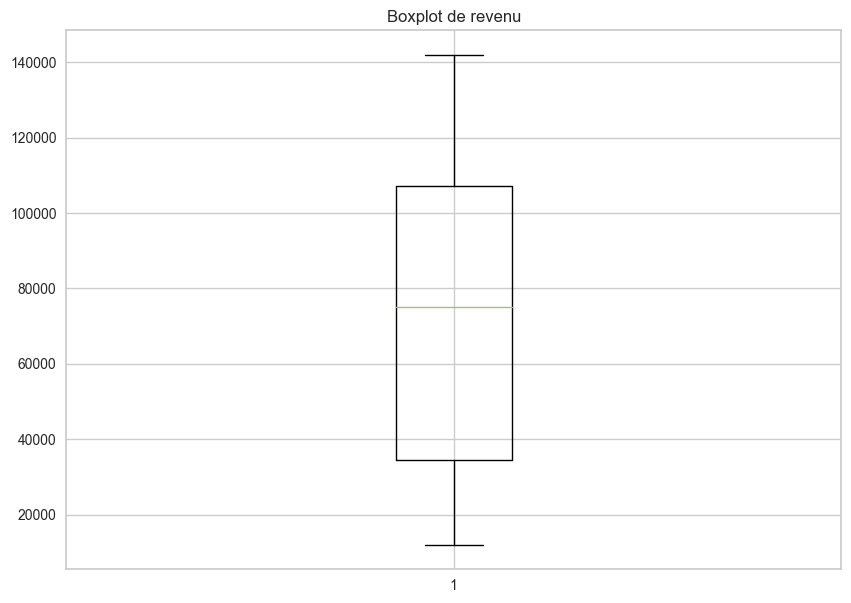

In [15]:
plt.figure(figsize=(10,7)) # papier
plt.boxplot(data['revenu']) # schema
plt.title('Boxplot de revenu')# titre
plt.legend()# legende
plt.show() # aff

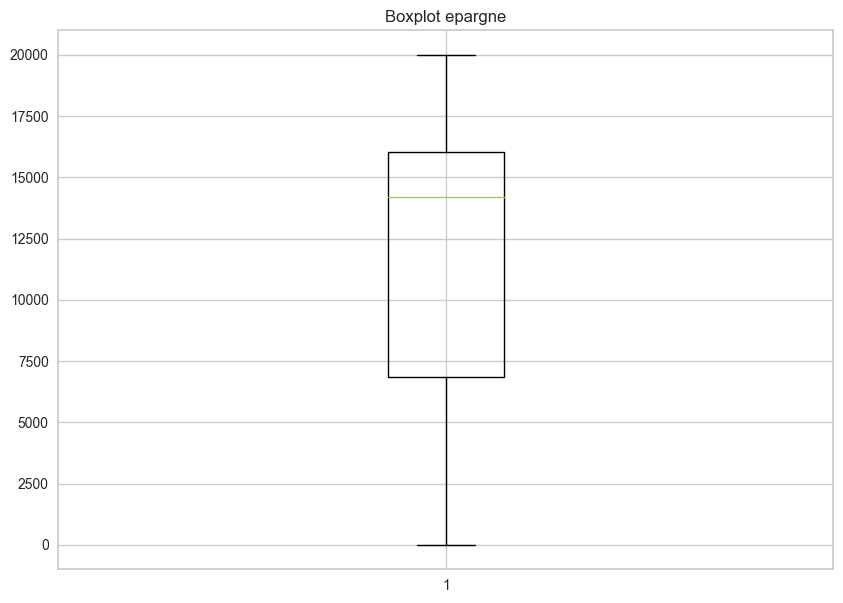

In [16]:
plt.figure(figsize=(10,7))
plt.boxplot(data['epargne'])
plt.title('Boxplot epargne')
plt.show()

### **III. Entraînement du modèle avec la bibliothèque PyCaret**
### **Un flux de travail typique dans le module non supervisé de PyCaret consiste en 6 étapes, dans cet ordre**:
**Setup ➡️ Create Model ➡️ Assign Labels ➡️ Analyze Model ➡️ Prediction ➡️ Save Model**

#### **1. Initialisation**
Cette fonction initialise l'environnement d'entraînement et crée le pipeline de transformation. La fonction `setup` doit être appelée avant toute autre fonction de PyCaret. Elle ne requiert qu'un seul paramètre : les données. Tous les autres paramètres sont facultatifs.

In [17]:
test_setup = setup(data = data, session_id=123, normalize=True) # Sans target( variable)

,Description,Value
0,Session id,123
1,Original data shape,"(505, 4)"
2,Transformed data shape,"(505, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


**Intépretation**: (Donnée original et donnée trasforme)\
Presque toutes les observations ont été utilisées pour entraîner le modèle, car l'objectif ici est de segmenter les données en 3 ou 4 groupes si possible, et non de prédire une valeur continue ou de faire une classification binaire.

#### **2. Comparaison entre différents modèles**
*La commande ``compare_models()`` ne fonctionne pas pour les problèmes de clustering. Nous procédons donc à une comparaison manuelle des modèles dans ce projet. Dans un premier temps, nous allons déterminer les algorithmes possibles, puis comparer leurs performances a partir de boucle for.*

In [18]:
models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch


In [19]:
model = ['kmeans','dbscan','ap']
for mod in model:
    print(f'Le model {mod}')
    create_model(mod)

Le model kmeans


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7325,1122.4249,0.3947,0,0,0


Le model dbscan


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.8049,3671.3580,0.2762,0,0,0


Le model ap


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.8049,3671.3580,0.2762,0,0,0


**Intérpretation**: Il faut garder à l’esprit lequel est le plus adapté à notre problématique
| Métrique          | Meilleur             |
| ----------------- | -------------------- |
| Silhouette        | 🔼 proche de **1**   |
| Calinski-Harabasz | 🔼 **le plus grand** |
| Davies-Bouldin    | 🔽 proche de **0**   |
| Homogeneity       | 🔼 proche de **1**   |
| Rand Index        | 🔼 proche de **1**   |
| Completeness      | 🔼 proche de **1**   |


D’après le tableau precedent, les algorithmes **Density-Based Spatial Clustering (DBSCAN) et Affinity Propagation (AP)** sont les plus performants. Toutefois, nous choisissons d’utiliser l’algorithme **DBSCAN**, car il est plus populaire et largement utilisé que **AP**.

#### **3. Création de modèle**
Cette fonction entraîne et évalue les performances d'un modèle donné. Les métriques évaluées sont accessibles via la fonction `get_metrics`. Il est possible d'ajouter ou de supprimer des métriques personnalisées à l'aide des fonctions `add_metric` et `remove_metric`. Tous les modèles disponibles sont accessibles via la fonction `models`.

In [20]:
best_model = create_model('dbscan',num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.8049,3671.3580,0.2762,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

#### **5. Evaluation de modèle**


In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### **6. Analyse graphique des performances du modèle**
Les differentes type de graphe de visualisation dans cette étude clustering sont:
| **Nom du plot**                    | **Objectif du plot**                                     | **Code PyCaret**                       |
| ---------------------------------- | -------------------------------------------------------- | -------------------------------------- |
| **Elbow Plot**                     | Choisir le nombre optimal de clusters (K)                | `plot_model(model, plot='elbow')`      |
| **Silhouette Plot**                | Évaluer la qualité de séparation des clusters            | `plot_model(model, plot='silhouette')` |
| **Cluster Plot**                   | Visualiser la séparation des clusters en 2D              | `plot_model(model, plot='cluster')`    |
| **PCA Plot**                       | Observer la structure globale via réduction de dimension | `plot_model(model, plot='pca')`        |
| **t-SNE Plot**                     | Détecter des structures non linéaires                    | `plot_model(model, plot='tsne')`       |
| **Dendrogram**                     | Identifier la hiérarchie et le nombre de clusters        | `plot_model(model, plot='dendrogram')` |
| **Distance Plot**                  | Visualiser les distances entre observations              | `plot_model(model, plot='distance')`   |


=>Nous allons utiliser un Cluster Plot ainsi qu’un Silhouette Plot pour visualiser la séparation des clusters en deux dimensions (2D) et évaluer la qualité de cette séparation.


La fonction `plot_model` permet d'analyser les performances d'un modèle entraîné sur l'ensemble de test. Dans certains cas, un réentraînement du modèle peut s'avérer nécessaire.

In [22]:
plot_model(best_model,'cluster')
# plot_model(best_model, plot='silhouette')

#### **7. Attribuer des étiquettes à partir du modèle entraîné**
**But**: Attribue des labels de cluster à nos données après avoir entraîné le modèle.

In [23]:
resultat = assign_model(best_model)
resultat.head()

,Age,revenu,depense,epargne,Cluster
0,58,77769,0.791329,6559.830078,Cluster 0
1,59,81799,0.791082,5417.661621,Cluster 0
2,62,74751,0.702657,9258.993164,Cluster 0
3,59,74373,0.765680,7346.334473,Cluster 0
4,87,17760,0.348778,16869.507812,Cluster 1


**Détermination du nombre de clusters et répartition (en pourcentage) des observations dans chaque cluster.**

In [24]:
print((resultat['Cluster'].value_counts())/resultat.shape[0]*100)
print('\n==============Le nombres des elementes a chaque cluster=============')
resultat['Cluster'].value_counts()

Cluster
Cluster 0    31.089109
Cluster 1    29.108911
Cluster 4    24.950495
Cluster 2     9.900990
Cluster 3     4.950495
Name: count, dtype: float64

==============Le nombres des elementes a chaque cluster=============


Cluster
Cluster 0    157
Cluster 1    147
Cluster 4    126
Cluster 2     50
Cluster 3     25
Name: count, dtype: int64

#### **8. Examiner les caractéristiques de chaque cluster**
Le problème ici est d’identifier ce que représentent les clusters 0, 1, etc. Pour mieux comprendre notre segmentation, nous allons analyser les statistiques descriptives de chaque cluster à l’aide de la méthode groupby

In [25]:
print('\n==============Moyenne a chaque cluster==============')
print(resultat.groupby('Cluster').mean())
print('\n==============Médiane a chaque cluster==============')
print(resultat.groupby('Cluster').median())


==============Moyenne a chaque cluster==============
                 Age         revenu   depense       epargne
Cluster                                                    
Cluster 0  59.955414   72448.063694  0.771518   6889.972168
Cluster 1  87.775510   27866.102041  0.328800  16659.261719
Cluster 2  24.180000  128029.120000  0.896892   4087.520264
Cluster 3  86.000000  119944.040000  0.068378  14808.683594
Cluster 4  32.777778  105265.809524  0.309926  14962.777344

==============Médiane a chaque cluster==============
            Age    revenu   depense       epargne
Cluster                                          
Cluster 0  59.0   72027.0  0.766720   6845.056641
Cluster 1  88.0   27771.0  0.324719  16711.068359
Cluster 2  24.5  128162.0  0.890676   4361.966797
Cluster 3  86.0  119429.0  0.063273  14773.407227
Cluster 4  33.0  106002.5  0.309479  14976.943359


#### **Résultats**
- Cluster 0 : Adulte plus âgé / Revenu élevé / Dépenses faibles / Épargne moyenne  
- Cluster 1 : Adulte / Revenu moyen / Dépenses élevées / Épargne faible  
- Cluster 2 : Adulte plus âgé / Revenu faible / Dépenses faibles / Épargne élevée  
- Cluster 3 : Adulte / Revenu élevé / Dépenses faibles / Épargne moyenne  
- Cluster 4 : Jeune / Revenu élevé / Dépenses élevées / Épargne faible


#### **9. Prédiction dans une nouvelle donnée**

In [27]:
new_data =  pd.DataFrame([{'Age': 25,
            'revenu':102220,
            'depense':0.50,
            'epargne':20021}])
predict_model(best_model,data=new_data)

TypeError: Model doesn't have the predict method.

**Remarque** : Il est important de noter que l'algorithme DBSCAN ne permet pas de faire de prédiction sur de nouvelles données, car il ne crée pas de modèle généralisable. Cela signifie qu’il ne peut pas attribuer un cluster à une nouvelle observation en dehors des données d’entraînement.

####    **Création d’un nouvel algorithme capable de faire une prédiction.(Kmeans)**

a) **Création de nouvelle model**

In [32]:
model2 = create_model('kmeans',num_clusters=4)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7325,1122.4249,0.3947,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

b) **Evaluation de modèle**

In [33]:
evaluate_model(model2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [34]:
plot_model(model2,plot='cluster')

**Remarque** : Ces résultats changent en fonction de nos nouvelles données, ce qui signifie que le modèle applique un prétraitement automatique, généralement une normalisation ou une standardisation.

In [35]:
new_data =  pd.DataFrame([{'Age': 25,
            'revenu':102220,
            'depense':0.50,
            'epargne':20021}])
predict_model(model2,data=new_data)

,Age,revenu,depense,epargne,Cluster
0,-1.410666,0.742735,-0.019596,1.650082,Cluster 3


In [36]:
save_model(model2,'../model/model_de_clustering')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Age', 'revenu', 'depense',
                                              'epargne'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('normalize', TransformerWrapper(transformer=StandardScaler())),
                 ('trained_model', KMeans(n_clusters=4, random_state=123))]),
 '../model/model_de_clustering.pkl')